In [ ]:
import sys
sys.path.append("..")

In [2]:
%load_ext autoreload
%autoreload 2

## Using Variational Inference Model

In this experiment, i'm trying to appproximate – in a unsupervised way – a normal distribution using variational inference loss  

In [5]:
from sympy.stats import Normal, sample
from sympy import symbols, Eq, Or
import numpy as np
from sympy.stats import P, Die

truth_mu = 2
truth_sigma = 1
x = Normal('x', truth_mu, truth_sigma)
noise = Normal('noise', 0, 1)
x = x + noise
num_samples = 100
samples_list = list(sample(x, size=num_samples))
samples_list = np.array(samples_list)

x_bold_train, x_bold_eval, x_bold_test = np.split(samples_list, [int(.6 * len(samples_list)), int(.8 * len(samples_list))]) 

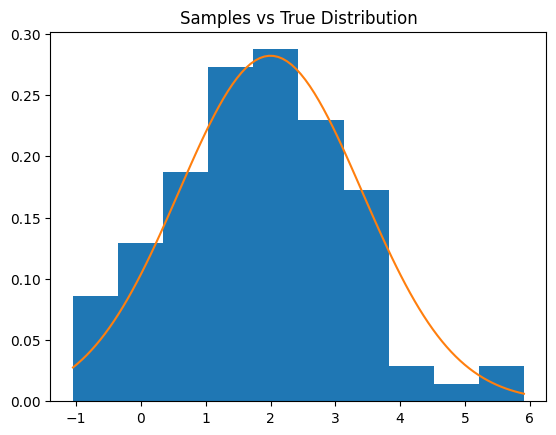

In [6]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import norm

x = np.linspace(min(samples_list), max(samples_list), 100)
pdf = norm.pdf(x, 2, np.sqrt(2))

plt.hist(samples_list, bins=10, density=True)
plt.plot(x, pdf)

plt.title("Samples vs True Distribution")
plt.show()

In [ ]:
from model.univariateGaussianVariationalModel import UnivariateGaussianVariationalModel

model = UnivariateGaussianVariationalModel()
initial_mu_est, initial_sigma_est = model.get_parameters()
model.fit(x_bold_train=x_bold_train, x_bold_val=x_bold_eval, learning_rate=0.0001, epochs=10, patience=10)
mu_est, sigma_est = model.get_parameters()
print("Estimated mu:", mu_est)
print("Estimated sigma:", sigma_est)

Model is not fitted yet.
New __has_improved called
New __has_improved called
New __has_improved called
New __has_improved called
New __has_improved called
New __has_improved called
New __has_improved called
New __has_improved called
New __has_improved called
New __has_improved called
Estimated mu: 1.88515270148367
Estimated sigma: 1


In [36]:
ground_truth_parameters = {"mu": 2, "sigma": 1}
initial_parameters = {"mu": initial_mu_est, "sigma": initial_sigma_est}
estimated_parameters = {"mu": mu_est, "sigma": sigma_est}

ground_truth_dist = norm(loc=ground_truth_parameters["mu"], scale=ground_truth_parameters["sigma"])
initial_dist = norm(loc=initial_parameters["mu"], scale=initial_parameters["sigma"])
estimated_dist = norm(loc=estimated_parameters["mu"], scale=estimated_parameters["sigma"])



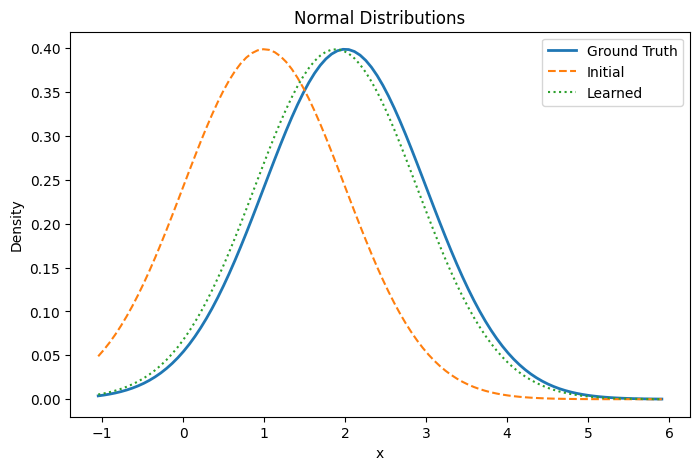

In [37]:
plt.figure(figsize=(8,5))

plt.plot(x, ground_truth_dist.pdf(x), label="Ground Truth", linewidth=2)
plt.plot(x, initial_dist.pdf(x), label="Initial", linestyle="--")
plt.plot(x, estimated_dist.pdf(x), label="Learned", linestyle=":")

plt.title("Normal Distributions")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()

plt.show()